<a href="https://colab.research.google.com/github/AnisaAisha/procedural-modeling-simulation-of-embroidery/blob/main/Motif_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
!pip install taichi
%matplotlib inline


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 19.8 MB/s eta 0:00:00


[Taichi] version 1.7.4, llvm 15.0.4, commit b4b956fd, linux, python 3.12.13


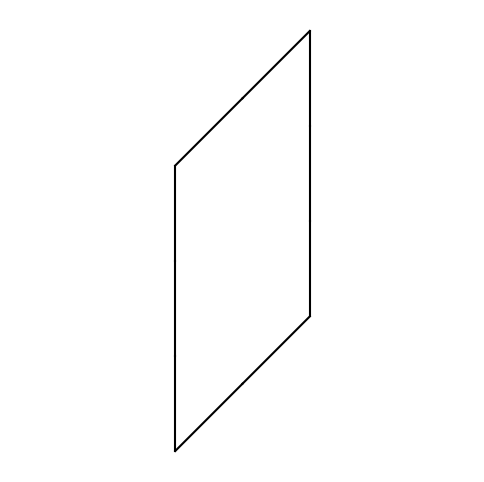

In [3]:
#SIMPLE PARALLELOGRAM INTERPRETER (cpu)
import taichi as ti
import math, matplotlib.pyplot as plt

segments = []
stack = []

def draw(commands, stepA=80, stepB=100, turn=15):
    pos = [0.0, 0.0]
    angle = 90
    for c in commands:
        if c == 'A':
            new_pos = [pos[0] + stepA*math.cos(math.radians(angle)),
                       pos[1] + stepA*math.sin(math.radians(angle))]
            segments.append((pos, new_pos))
            pos = new_pos
        elif c == 'B':
            new_pos = [pos[0] + stepB*math.cos(math.radians(angle)),
                       pos[1] + stepB*math.sin(math.radians(angle))]
            segments.append((pos, new_pos))
            pos = new_pos
        elif c == 'a':
            pos = [pos[0] + stepA*math.cos(math.radians(angle)),
                   pos[1] + stepA*math.sin(math.radians(angle))]
        elif c == '+':
            angle -= turn
        elif c == '-':
            angle += turn
        elif c == '[':
            stack.append((pos[:], angle))
        elif c == ']':
            pos, angle = stack.pop()

def show():
    plt.figure(figsize=(6,6))
    for (p1,p2) in segments:
        plt.plot([p1[0],p2[0]], [p1[1],p2[1]], 'k-')
    plt.axis('equal'); plt.axis('off')
    plt.show()

command = "AAA---------AA---AAA---------AA---"
draw(command,stepA=80, stepB=100, turn=15)
show()

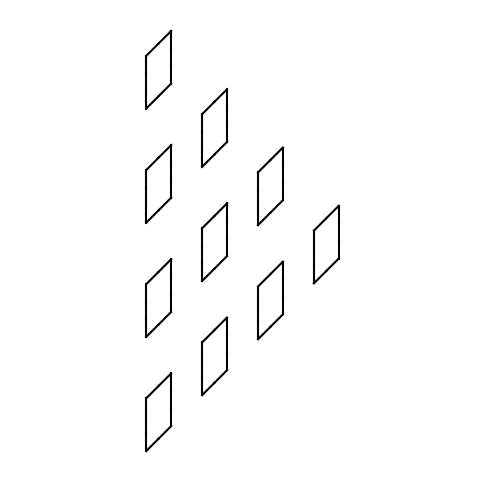

In [4]:
import math, matplotlib.pyplot as plt

segments = []
stack = []

def turtle_draw(commands, stepA=80, stepB=100, turn=15, start_pos=(0,0), start_angle=90):
    pos = list(start_pos)
    angle = start_angle
    for c in commands:
        if c == 'A':  # forward + draw
            new_pos = [pos[0] + stepA*math.cos(math.radians(angle)),
                       pos[1] + stepA*math.sin(math.radians(angle))]
            segments.append((pos, new_pos))
            pos = new_pos
        elif c == 'B':  # forward + draw with different length
            new_pos = [pos[0] + stepB*math.cos(math.radians(angle)),
                       pos[1] + stepB*math.sin(math.radians(angle))]
            segments.append((pos, new_pos))
            pos = new_pos
        elif c == 'a':  # forward without drawing
            pos = [pos[0] + stepA*math.cos(math.radians(angle)),
                   pos[1] + stepA*math.sin(math.radians(angle))]
        elif c == '+':  # clockwise
            angle -= turn
        elif c == '-':  # anticlockwise
            angle += turn
        elif c == '[':  # push state
            stack.append((pos[:], angle))
        elif c == ']':  # pop state
            pos, angle = stack.pop()
    return pos, angle

def show():
    plt.figure(figsize=(6,6))
    for (p1,p2) in segments:
        plt.plot([p1[0],p2[0]], [p1[1],p2[1]], 'k-')
    plt.axis('equal'); plt.axis('off')
    plt.show()

# Parallelogram axiom
parallelogram_axiom = "AAA---------AA---AAA---------AA---"

# Clear segments
segments.clear()

# 1. CALCULATE EXACT GEOMETRY (stepA = 20)
# Vertical side is 3 'A's (3 * 20 = 60)
vertical_height = 60.0

# The vertical gap you requested between each parallelogram in a column
gap_between_rows = 70.0

# Slanted side is 2 'A's (40) at a 45-degree angle
# We add your 70 unit gap between each column along this diagonal path!
gap_between_cols = 50
total_diagonal_step = 40.0 + gap_between_cols

# This gives us the exact X and Y shifts to follow the diagonal with the new gap!
shift_x = total_diagonal_step * math.cos(math.radians(45))
shift_y = total_diagonal_step * math.sin(math.radians(45))

start_x, start_y = 0.0, 0.0
n = 4

# 2. THE CORRECTED LOOP
for j in range(n):
    # Use a temporary Y variable to stack shapes within the current column
    current_y = start_y

    for i in range(n - j):
        turtle_draw(parallelogram_axiom, stepA=20, turn=15,
                    start_pos=(start_x, current_y), start_angle=90)

        # Shift UP by exactly the height of one vertical edge PLUS your 100-step gap
        current_y += vertical_height + gap_between_rows

    # THE FIX: After the column is finished, we modify the base coordinates
    # to move up and to the right, exactly along the slanted edge of the bottom shape!
    start_x += shift_x
    start_y += shift_y

# Show result
show()


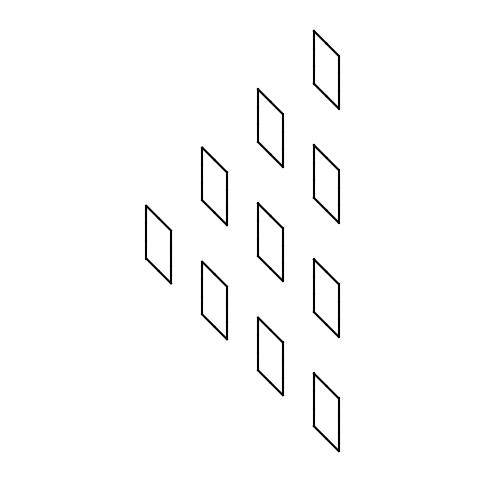

In [5]:
import math, matplotlib.pyplot as plt

segments = []
stack = []

def turtle_draw(commands, stepA=80, stepB=100, turn=15, start_pos=(0,0), start_angle=90):
    pos = list(start_pos)
    angle = start_angle
    for c in commands:
        if c == 'A':  # forward + draw
            new_pos = [pos[0] + stepA*math.cos(math.radians(angle)),
                       pos[1] + stepA*math.sin(math.radians(angle))]
            segments.append((pos, new_pos))
            pos = new_pos
        elif c == 'B':  # forward + draw with different length
            new_pos = [pos[0] + stepB*math.cos(math.radians(angle)),
                       pos[1] + stepB*math.sin(math.radians(angle))]
            segments.append((pos, new_pos))
            pos = new_pos
        elif c == 'a':  # forward without drawing
            pos = [pos[0] + stepA*math.cos(math.radians(angle)),
                   pos[1] + stepA*math.sin(math.radians(angle))]
        elif c == '+':  # clockwise
            angle -= turn
        elif c == '-':  # anticlockwise
            angle += turn
        elif c == '[':  # push state
            stack.append((pos[:], angle))
        elif c == ']':  # pop state
            pos, angle = stack.pop()
    return pos, angle

def show():
    plt.figure(figsize=(6,6))
    for (p1,p2) in segments:
        # THE FLIP: By making the X coordinates negative (-p1[0], -p2[0]),
        # the entire image is perfectly mirrored to the left!
        plt.plot([-p1[0],-p2[0]], [p1[1],p2[1]], 'k-')
    plt.axis('equal'); plt.axis('off')
    plt.show()

# Parallelogram axiom
parallelogram_axiom = "AAA---------AA---AAA---------AA---"

# Clear segments
segments.clear()

# 1. CALCULATE EXACT GEOMETRY (stepA = 20)
# Vertical side is 3 'A's (3 * 20 = 60)
vertical_height = 60.0

# The vertical gap you requested between each parallelogram in a column
gap_between_rows = 70.0

# Slanted side is 2 'A's (40) at a 45-degree angle
# We add your 50 unit gap between each column along this diagonal path!
gap_between_cols = 50.0
total_diagonal_step = 40.0 + gap_between_cols

# This gives us the exact X and Y shifts to follow the diagonal with the new gap!
shift_x = total_diagonal_step * math.cos(math.radians(45))
shift_y = total_diagonal_step * math.sin(math.radians(45))

start_x, start_y = 0.0, 0.0
n = 4

# 2. THE CORRECTED LOOP
for j in range(n):
    # Use a temporary Y variable to stack shapes within the current column
    current_y = start_y

    for i in range(n - j):
        turtle_draw(parallelogram_axiom, stepA=20, turn=15,
                    start_pos=(start_x, current_y), start_angle=90)

        # Shift UP by exactly the height of one vertical edge PLUS your gap
        current_y += vertical_height + gap_between_rows

    # THE FIX: After the column is finished, we modify the base coordinates
    # to move up and to the right, exactly along the slanted edge of the bottom shape!
    start_x += shift_x
    start_y += shift_y

# Show result
show()

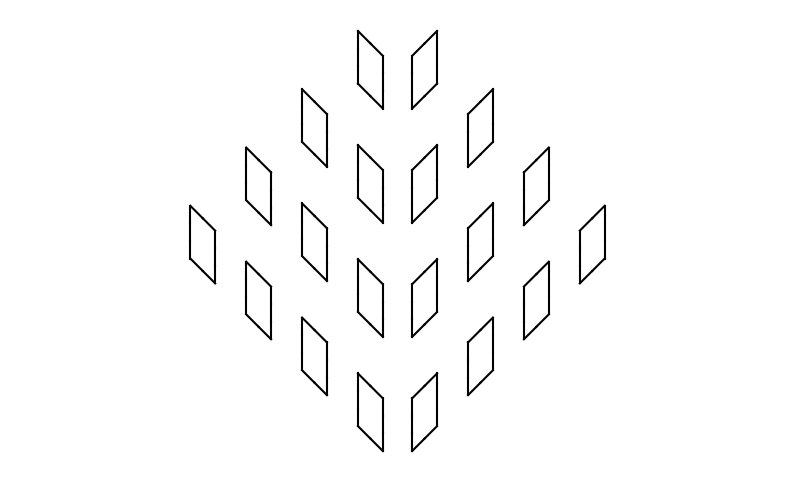

In [6]:
import math, matplotlib.pyplot as plt

segments = []
stack = []

def turtle_draw(commands, stepA=80, stepB=100, turn=15, start_pos=(0,0), start_angle=90):
    pos = list(start_pos)
    angle = start_angle
    for c in commands:
        if c == 'A':  # forward + draw
            new_pos = [pos[0] + stepA*math.cos(math.radians(angle)),
                       pos[1] + stepA*math.sin(math.radians(angle))]
            segments.append((pos, new_pos))
            pos = new_pos
        elif c == 'B':  # forward + draw with different length
            new_pos = [pos[0] + stepB*math.cos(math.radians(angle)),
                       pos[1] + stepB*math.sin(math.radians(angle))]
            segments.append((pos, new_pos))
            pos = new_pos
        elif c == 'a':  # forward without drawing
            pos = [pos[0] + stepA*math.cos(math.radians(angle)),
                   pos[1] + stepA*math.sin(math.radians(angle))]
        elif c == '+':  # clockwise
            angle -= turn
        elif c == '-':  # anticlockwise
            angle += turn
        elif c == '[':  # push state
            stack.append((pos[:], angle))
        elif c == ']':  # pop state
            pos, angle = stack.pop()
    return pos, angle

def generate_base_motif():
    """Generates the coordinate segments for a single right-facing motif."""
    parallelogram_axiom = "AAA---------AA---AAA---------AA---"

    vertical_height = 60.0
    gap_between_rows = 70.0
    gap_between_cols = 50.0

    total_diagonal_step = 40.0 + gap_between_cols
    shift_x = total_diagonal_step * math.cos(math.radians(45))
    shift_y = total_diagonal_step * math.sin(math.radians(45))

    start_x, start_y = 0.0, 0.0
    n = 4

    for j in range(n):
        current_y = start_y
        for i in range(n - j):
            turtle_draw(parallelogram_axiom, stepA=20, turn=15,
                        start_pos=(start_x, current_y), start_angle=90)
            current_y += vertical_height + gap_between_rows

        start_x += shift_x
        start_y += shift_y

def plot_right_motif(offset):
    """Plots the right-facing motif with a given X offset."""
    for (p1, p2) in segments:
        plt.plot([p1[0] + offset, p2[0] + offset], [p1[1], p2[1]], 'k-')

def plot_left_motif(offset):
    """Plots the left-facing (flipped) motif with a given X offset."""
    for (p1, p2) in segments:
        plt.plot([-p1[0] - offset, -p2[0] - offset], [p1[1], p2[1]], 'k-')

def show(center_gap):
    """Sets up the canvas and calls the plotting functions."""
    plt.figure(figsize=(10, 6))

    center_offset = center_gap / 2.0

    # Call our two separate functions to draw the right and flipped images!
    plot_right_motif(center_offset)
    plot_left_motif(center_offset)

    plt.axis('equal'); plt.axis('off')
    plt.show()

def render_motif(center_gap=50.0):
    """
    Main wrapper function to clear, generate, and render the complete Motif 1.
    This makes the entire file act as a clean, reusable module.
    """
    # 1. Clear previous drawings
    segments.clear()

    # 2. Generate the base coordinates
    generate_base_motif()

    # 3. Render both motifs side-by-side with the specified gap
    show(center_gap)

# ==========================================
# MAIN EXECUTION
# ==========================================
if __name__ == "__main__":
    render_motif(center_gap=90.0)


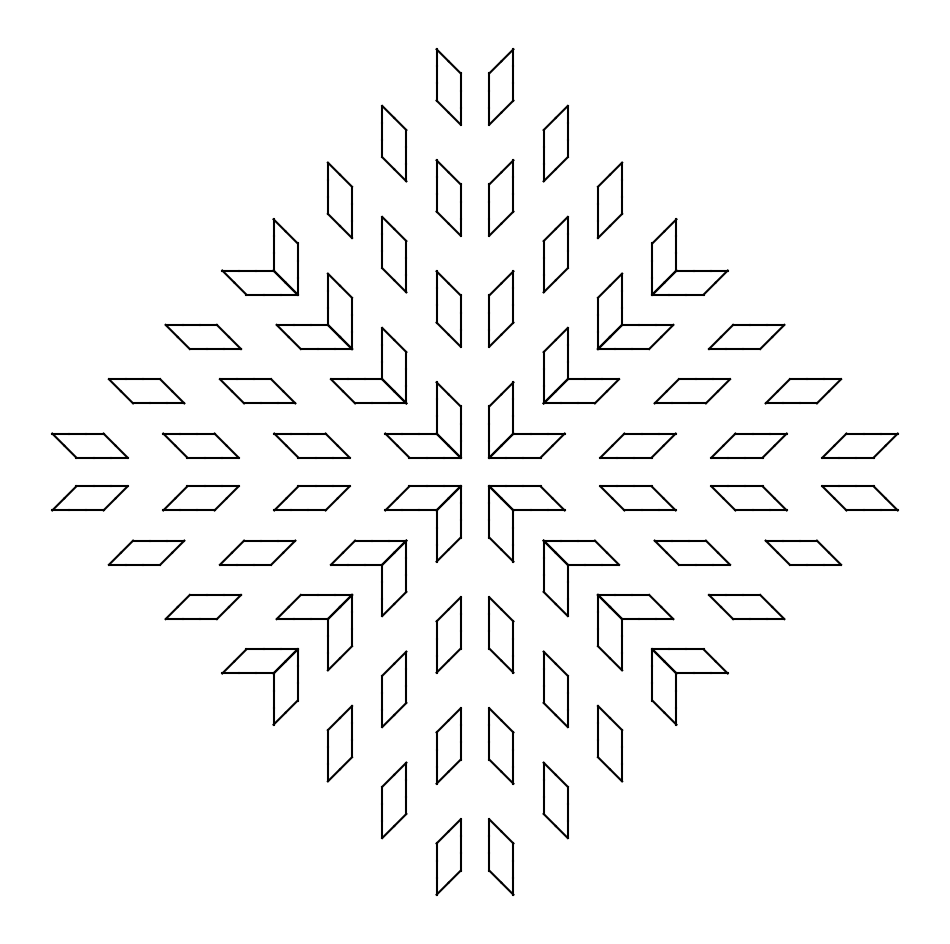

In [7]:
import math, matplotlib.pyplot as plt
import taichi as ti

segments = []
stack = []

def turtle_draw(commands, stepA=80, stepB=100, turn=15, start_pos=(0,0), start_angle=90):
    pos = list(start_pos)
    angle = start_angle
    for c in commands:
        if c == 'A':  # forward + draw
            new_pos = [pos[0] + stepA*math.cos(math.radians(angle)),
                       pos[1] + stepA*math.sin(math.radians(angle))]
            segments.append((pos, new_pos))
            pos = new_pos
        elif c == 'B':  # forward + draw with different length
            new_pos = [pos[0] + stepB*math.cos(math.radians(angle)),
                       pos[1] + stepB*math.sin(math.radians(angle))]
            segments.append((pos, new_pos))
            pos = new_pos
        elif c == 'a':  # forward without drawing
            pos = [pos[0] + stepA*math.cos(math.radians(angle)),
                   pos[1] + stepA*math.sin(math.radians(angle))]
        elif c == '+':  # clockwise
            angle -= turn
        elif c == '-':  # anticlockwise
            angle += turn
        elif c == '[':  # push state
            stack.append((pos[:], angle))
        elif c == ']':  # pop state
            pos, angle = stack.pop()
    return pos, angle

def generate_base_motif():
    """Generates the coordinate segments for a single right-facing motif."""
    parallelogram_axiom = "AAA---------AA---AAA---------AA---"

    vertical_height = 60.0
    gap_between_rows = 70.0
    gap_between_cols = 50.0

    total_diagonal_step = 40.0 + gap_between_cols
    shift_x = total_diagonal_step * math.cos(math.radians(45))
    shift_y = total_diagonal_step * math.sin(math.radians(45))

    start_x, start_y = 0.0, 0.0
    n = 4

    for j in range(n):
        current_y = start_y
        for i in range(n - j):
            turtle_draw(parallelogram_axiom, stepA=20, turn=15,
                        start_pos=(start_x, current_y), start_angle=90)
            current_y += vertical_height + gap_between_rows

        start_x += shift_x
        start_y += shift_y

def plot_rotated_arm(offset, radial_offset, angle_deg):
    """Plots a full arm (right + left halves) rotated by a specific angle around the center."""
    theta = math.radians(angle_deg)
    cos_t = math.cos(theta)
    sin_t = math.sin(theta)

    # Simple 2D rotation matrix function
    def rotate(x, y):
        return x * cos_t - y * sin_t, x * sin_t + y * cos_t

    for (p1, p2) in segments:
        # 1. Right-facing half (shifted right by offset, pushed outward by radial_offset)
        rx1, ry1 = p1[0] + offset, p1[1] + radial_offset
        rx2, ry2 = p2[0] + offset, p2[1] + radial_offset

        # Apply rotation and plot
        rrx1, rry1 = rotate(rx1, ry1)
        rrx2, rry2 = rotate(rx2, ry2)
        plt.plot([rrx1, rrx2], [rry1, rry2], 'k-')

        # 2. Left-facing half (flipped X, shifted left by offset, pushed outward by radial_offset)
        lx1, ly1 = -p1[0] - offset, p1[1] + radial_offset
        lx2, ly2 = -p2[0] - offset, p2[1] + radial_offset

        # Apply rotation and plot
        rlx1, rly1 = rotate(lx1, ly1)
        rlx2, rly2 = rotate(lx2, ly2)
        plt.plot([rlx1, rlx2], [rly1, rly2], 'k-')

def show(center_gap, radial_gap):
    """Sets up the canvas and calls the plotting functions."""
    # Made the canvas a large square to perfectly fit the 4-way symmetrical star
    plt.figure(figsize=(12, 12))

    center_offset = center_gap / 2.0

    # Call the new function 4 times at the requested angles!
    for angle in [0, 90, 180, 270]:
        plot_rotated_arm(center_offset, radial_gap, angle)

    plt.axis('equal'); plt.axis('off')
    plt.show()

def render_motif(center_gap=50.0, radial_gap=150.0):
    """
    Main wrapper function to clear, generate, and render the complete Motif 1.
    This makes the entire file act as a clean, reusable module.
    """
    # 1. Clear previous drawings
    segments.clear()

    # 2. Generate the base coordinates
    generate_base_motif()

    # 3. Render the 4-way motif with the specified gaps
    show(center_gap, radial_gap)

# ==========================================
# MAIN EXECUTION
# ==========================================
if __name__ == "__main__":
    # gap btw each repeated aptterns
    render_motif(center_gap=90.0, radial_gap=45.0)
